In [3]:
import os
import sys
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from pathlib import Path
import pickle

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import to_hex
from matplotlib.lines import Line2D
import seaborn as sns

# 1. Data Preparation

In [ ]:
%load_ext autoreload
%autoreload
import chip_utilities as utils

sys.path.insert(0, '..')
import sigmoid_fitting as sp
from experiment_data_loader import ExperimentDataLoader

exp_folder = "/Users/kautsarg/Documents/Final Project/Run Data/trial test data"
# exp_paths = [Path(exp_folder, name) for name in os.listdir(exp_folder) if name != ".DS_Store"]
exp_path = Path(exp_folder, "D20250808_E00_C00_F4500KHz_U_Sample_7")

data_path = os.path.join(exp_path, "curve_for_training_2.pkl")

with open(data_path, 'rb') as f:
    training_data = pickle.load(f)

timestamps = training_data["timestamps"]
Y_well = training_data["Y_well"]
dataset_name = training_data["dataset_name"]
dataset = training_data["dataset"]
kinetic_features = training_data["kinetic_features"]

curve_path = Path(exp_path, "preprocessed_curves_data.pkl")
with open(curve_path, 'rb') as f:
    processed_curve_results = pickle.load(f)
    
metadata_df = pd.DataFrame(processed_curve_results["metadata"])

for i in range(len(kinetic_features)):
    kinetic_features[i] = pd.concat([kinetic_features[i],metadata_df], axis=1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
# for name, kf in zip(dataset_name, kinetic_features):
#     print("="*75)
#     print(name)
#     print(np.sum(kf.isna(),axis=0))
#     print("="*75)

kinetic_features[0].columns

Index(['Fm', 'Fb', 'Sc', 'Cs', 'As', 'Send', 'Send_abs', 'Send_fit',
       'Send_fit_abs', 'F_max', 'ct_idx', '5p_sigmoid_fitted',
       '5p_sigmoid_fitted_dydx', 'xms', 'xs', 'xe', 'xp1', 'xp2', 'TH',
       'y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'dy_xms', 'dy_xp1', 'dy_xp2',
       'd2y_xp1', 'd2y_xp2', 'threshold_distance', 'first_half_distance',
       'second_half_distance', 'distance_asymmetry_index',
       'peak_shifting_distance', 'A1', 'A2', 'area_asymmetry_index',
       'peak_asymmetry_index', 'Ct', 'Cy0', 'log_F0', 'F0', 'msc_mahal_dist',
       'msc_label_0.001', 'amf_label_Send', 'amf_label_Send_abs',
       'amf_label_Send_fit', 'amf_label_Send_fit_abs',
       'mean_std_outlier_label_3sigma', 'pixel_row_idx', 'pixel_col_idx',
       'temp_group_idx', 'num_active_pixels_in_temp_group',
       'well_temp_lin2d_mean', 'well_2d_temp_npr_mean'],
      dtype='object')

# 2. Additional Features Extraction

In [73]:
def get_send(timestamps, curves_2d, send_n=[5, 10, 15, 20, 25]):
    dy_dx_list = Parallel(n_jobs=-1, backend="loky", batch_size='auto')(
        delayed(sp.calculate_first_derivative)(timestamps, y) for y in curves_2d
    )
    dy_dx = np.array(dy_dx_list) 
    
    send_dict = {}
    for n in send_n:
        send_dict[f"send_{n}"] = np.nanmean(dy_dx[:, -n:], axis=1)
        
    return send_dict

for idx, (name, features_df, curves_2d) in enumerate(zip(dataset_name, kinetic_features, dataset)):
    add_features = get_send(timestamps, curves_2d)
    add_features["FFI"] = curves_2d[:, -1]    
    add_features["F_range"] = curves_2d[:, -1] - curves_2d[:, 0]

    df_new_features = pd.DataFrame(add_features).reset_index(drop=True)
    
    features_df = features_df.reset_index(drop=True)
    kinetic_features[idx] = pd.concat([features_df, df_new_features], axis=1)

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_28573/3307548350.py:9: RuntimeWarning: Mean of empty slice
  send_dict[f"send_{n}"] = np.nanmean(dy_dx[:, -n:], axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_28573/3307548350.py:9: RuntimeWarning: Mean of empty slice
  send_dict[f"send_{n}"] = np.nanmean(dy_dx[:, -n:], axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_28573/3307548350.py:9: RuntimeWarning: Mean of empty slice
  send_dict[f"send_{n}"] = np.nanmean(dy_dx[:, -n:], axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_28573/3307548350.py:9: RuntimeWarning: Mean of empty slice
  send_dict[f"send_{n}"] = np.nanmean(dy_dx[:, -n:], axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_28573/3307548350.py:9: RuntimeWarning: Mean of empty slice
  send_dict[f"send_{n}"] = np.nanmean(dy_dx[:, -n:], axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_28573/3307548350.py:9: RuntimeWarning: Mean of

# 3. Feature Linear Correlation Check

In [93]:
a = features_df.select_dtypes(include=['number', 'float', 'int']).columns
b = features_df.columns
list(set(a).symmetric_difference(set(b)))

['5p_sigmoid_fitted', '5p_sigmoid_fitted_dydx']

In [98]:
a.shape

(60,)

In [141]:
import os
import base64
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ====================================================================
# FEATURE GROUPS & EXCLUSIONS SETUP
# ====================================================================
feature_groups = {
    'A': ['send_5', 'send_10', 'send_15', 'send_20', 'send_25', 'Send', 'Send_abs', 'Send_fit', 'Send_fit_abs'],
    'B': ['F_max', 'Fm', 'FFI', 'F_range'],
    'C': ['ct_idx', 'Ct'],
    'D': ['log_F0', 'F0'],
    'E': ['y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2'],
    'F': ['dy_xms', 'dy_xp1', 'dy_xp2', 'd2y_xp1', 'd2y_xp2']
}

excluded_features = [
    'TH', 'msc_mahal_dist', 'msc_label_0.001', 'amf_label_Send', 
    'amf_label_Send_abs', 'amf_label_Send_fit', 'amf_label_Send_fit_abs', 
    'mean_std_outlier_label_3sigma'
]

# Create a reverse mapping dictionary to quickly check a feature's group
feature_to_group = {}
for grp_name, feats in feature_groups.items():
    for f in feats:
        feature_to_group[f] = grp_name

# 1. Initialize the master list of lists
linear_feature_combinations = []


# ====================================================================
# HTML & HEATMAP GENERATION
# ====================================================================
html_content = """
<html>
<head><title>Correlation Heatmaps</title></head>
<body style="font-family: Arial, sans-serif; background-color: #f4f4f9; text-align: center;">
    <h1 style="padding: 20px;">Experiment Correlation Heatmaps</h1>
"""

for name, features_df in zip(dataset_name, kinetic_features):
    clean_title = name.replace("_", " ").title()
    print(f"Generating heatmap and feature combinations for: {clean_title}...")
    
    # Select numeric features and calculate correlation
    numeric_df = features_df.select_dtypes(include=['number', 'float', 'int'])
    corr = numeric_df.corr()
    
    # ----------------------------------------------------------------
    # EXTRACT FEATURE COMBINATIONS (WITH RULES 6, 7, 8)
    # ----------------------------------------------------------------
    corr_abs = corr.abs() 
    dataset_combinations = []
    seen_combinations = set() # To track uniqueness (Rule 8)
    
    valid_features = [f for f in corr_abs.columns if f not in excluded_features]
    
    for base_feat in valid_features:
        corrs_for_feat = corr_abs[base_feat].copy()
        
        # Rule 6: Correlation value has to be >= 0.5
        corrs_for_feat = corrs_for_feat[corrs_for_feat >= 0.5]
        
        # Build a set of features to ignore
        feats_to_ignore = set([base_feat]) | set(excluded_features)
        
        # If the feature belongs to a group, ignore all other features in that same group
        if base_feat in feature_to_group:
            grp = feature_to_group[base_feat]
            feats_to_ignore.update(feature_groups[grp])
            
        # Drop features we are ignoring
        feats_to_drop_existing = list(feats_to_ignore.intersection(corrs_for_feat.index))
        corrs_for_feat = corrs_for_feat.drop(index=feats_to_drop_existing)
        
        # Rule 7: If the correlated feature count < 2, don't append anything
        if len(corrs_for_feat) < 2:
            continue
        
        # Grab the top 2 highest correlated features remaining
        top_2 = corrs_for_feat.sort_values(ascending=False).head(2).index.tolist()
        
        # Create the combination
        comb = [base_feat] + top_2
        
        # Rule 8: Make sure the combination is uniquely recorded for this dataset
        # Sorting it ensures [A, B, C] is identical to [B, A, C]
        comb_signature = tuple(sorted(comb))
        
        if comb_signature not in seen_combinations:
            seen_combinations.add(comb_signature)
            dataset_combinations.append(comb)
        
    # Append this dataset's unique combinations to the master list
    linear_feature_combinations.append(dataset_combinations)
    # ----------------------------------------------------------------

    # Apply the mask for the heatmap visualization (values < 0.5 become 0)
    corr_viz = corr.mask(corr.abs() < 0.5, 0)
    
    # MASSIVE figure size so columns don't overlap
    fig, ax = plt.subplots(figsize=(24, 20))
    
    # Plot heatmap
    sns.heatmap(corr_viz, cmap="coolwarm", center=0, 
                xticklabels=True, yticklabels=True, 
                linewidths=0.5, linecolor='lightgrey', 
                cbar_kws={"shrink": .75}, ax=ax)
    
    # Shrink label sizes and rotate them to fit columns perfectly
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
    
    plt.title(f"Correlation Matrix: {clean_title}", fontsize=22, fontweight='bold', pad=20)
    plt.tight_layout()
    
    # Save plot to a temporary memory buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.close(fig) 
    buf.seek(0)
    
    # Encode to Base64 and embed as an image tag in the HTML
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    
    html_content += f'''
    <div style="margin: 40px auto; width: 95%; background: white; padding: 20px; box-shadow: 0px 4px 10px rgba(0,0,0,0.1);">
        <img src="data:image/png;base64,{img_base64}" style="max-width: 100%; height: auto;">
    </div>
    '''

# Close the HTML and write the single file to disk
html_content += "</body></html>"

save_path = os.path.join(exp_path, "all_correlation_heatmaps.html")
with open(save_path, "w") as f:
    f.write(html_content)

print(f"\n  -> Successfully saved all heatmaps to {save_path}")
print(f"  -> Generated uniquely matched feature combinations for all {len(linear_feature_combinations)} datasets.")

Generating heatmap and feature combinations for: Ori Curves...
Generating heatmap and feature combinations for: Ori Curves Avg...
Generating heatmap and feature combinations for: Original Fitted Full...
Generating heatmap and feature combinations for: Original Fitted Stretched...
Generating heatmap and feature combinations for: Cleaned Std Fitted Full...
Generating heatmap and feature combinations for: Cleaned Std Fitted Stretched...
Generating heatmap and feature combinations for: Cleaned Lowest Fitted Full...
Generating heatmap and feature combinations for: Cleaned Lowest Fitted Stretched...
Generating heatmap and feature combinations for: Avg Fitted Full...
Generating heatmap and feature combinations for: Avg Fitted Stretched...
Generating heatmap and feature combinations for: Avg Cleaned Std Fitted Full...
Generating heatmap and feature combinations for: Avg Cleaned Std Fitted Stretched...
Generating heatmap and feature combinations for: Avg Cleaned Lowest Fitted Full...
Generating

In [144]:
import os
import gc
import base64
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Ensure we have categorical colors for the dots
try:
    # Attempt to use Y_well to color-code the specific wells
    colors = pd.factorize(Y_well)[0]
    cmap = 'tab10'
except NameError:
    # Fallback to a solid color if Y_well is not loaded
    colors = '#3498db'
    cmap = None

# 2. Initialize the Master HTML string
html_content = """
<html>
<head><title>3D Feature Combinations</title></head>
<body style="font-family: Arial, sans-serif; background-color: #f4f4f9; text-align: center; margin: 0; padding: 20px;">
    <h1 style="color: #333; margin-bottom: 10px;">3D Scatter Plots for Correlated Feature Combinations</h1>
    <p style="color: #666; margin-bottom: 40px;">X = Base Feature | Y & Z = Top 2 Correlated Features</p>
"""

for name, kf, dataset_combs in zip(dataset_name, kinetic_features, linear_feature_combinations):
    clean_title = name.replace("_", " ").title()
    print(f"Generating 3D plots for dataset: {clean_title}...")
    
    # Add a section header for the dataset
    html_content += f"<hr style='border: 1px solid #ddd; margin: 40px 0;'>"
    html_content += f"<h2 style='color: #2c3e50; font-size: 28px;'>Dataset: {clean_title}</h2>"
    
    # Start a Flexbox container for this dataset's grid of plots
    html_content += "<div style='display: flex; flex-wrap: wrap; justify-content: center; gap: 20px;'>"
    
    for comb in dataset_combs:
        # Failsafe: ensure the combination actually has 3 features
        if len(comb) < 3:
            continue 
            
        x_feat, y_feat, z_feat = comb[:3]
        
        # Sanitize data to prevent t-SNE / Matplotlib crashes
        df_3d = kf[[x_feat, y_feat, z_feat]].replace([np.inf, -np.inf], np.nan).fillna(0)
        X_vals = df_3d.values
        
        # Create the 3D figure
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        
        if cmap:
            ax.scatter(X_vals[:, 0], X_vals[:, 1], X_vals[:, 2], c=colors, cmap=cmap, s=30, alpha=0.8, edgecolor='k')
        else:
            ax.scatter(X_vals[:, 0], X_vals[:, 1], X_vals[:, 2], color=colors, s=30, alpha=0.8, edgecolor='k')
        
        ax.set_title(f"Base Feature: {x_feat}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel(x_feat, fontsize=10, fontweight='bold')
        ax.set_ylabel(y_feat, fontsize=10, fontweight='bold')
        ax.set_zlabel(z_feat, fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        
        # Save plot to memory
        buf = BytesIO()
        plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        buf.seek(0)
        
        # Encode and embed
        img_base64 = base64.b64encode(buf.read()).decode('utf-8')
        
        html_content += f'''
        <div style="background: white; padding: 15px; box-shadow: 0px 4px 8px rgba(0,0,0,0.05); border-radius: 8px; width: 45%; min-width: 400px; max-width: 600px;">
            <img src="data:image/png;base64,{img_base64}" style="width: 100%; height: auto;">
        </div>
        '''
        
    # Close the flexbox container for this dataset
    html_content += "</div>"
    
    # Run garbage collector aggressively to prevent out-of-memory crashes
    gc.collect()

# 3. Close the HTML and write to disk
html_content += "</body></html>"

save_path = os.path.join(exp_path, "all_feature_combinations_3D.html")
with open(save_path, "w") as f:
    f.write(html_content)

print(f"\n  -> Successfully saved all 3D combination plots to {save_path}")

Generating 3D plots for dataset: Ori Curves...
Generating 3D plots for dataset: Ori Curves Avg...
Generating 3D plots for dataset: Original Fitted Full...
Generating 3D plots for dataset: Original Fitted Stretched...
Generating 3D plots for dataset: Cleaned Std Fitted Full...
Generating 3D plots for dataset: Cleaned Std Fitted Stretched...
Generating 3D plots for dataset: Cleaned Lowest Fitted Full...
Generating 3D plots for dataset: Cleaned Lowest Fitted Stretched...
Generating 3D plots for dataset: Avg Fitted Full...
Generating 3D plots for dataset: Avg Fitted Stretched...
Generating 3D plots for dataset: Avg Cleaned Std Fitted Full...
Generating 3D plots for dataset: Avg Cleaned Std Fitted Stretched...
Generating 3D plots for dataset: Avg Cleaned Lowest Fitted Full...
Generating 3D plots for dataset: Avg Cleaned Lowest Fitted Stretched...

  -> Successfully saved all 3D combination plots to /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U

```
import pandas as pd

# 1. Calculate the absolute correlation matrix
corr_matrix = df.corr(method='pearson').abs()

# 2. Unstack to get pairs and drop self-correlations (where value is 1.0)
# We also drop duplicates since (A, B) is the same as (B, A)
pairs = corr_matrix.unstack()
pairs = pairs[pairs < 1.0].drop_duplicates()

# 3. Sort by strongest linear relationship
sorted_pairs = pairs.sort_values(ascending=False)

# 4. Extract the top 3 unique features from these strongest pairs
top_features = set()
for index, value in sorted_pairs.items():
    feature_1, feature_2 = index
    top_features.add(feature_1)
    top_features.add(feature_2)
    
    # Stop once we have exactly 3 features
    if len(top_features) >= 3:
        # If we accidentally grabbed 4 because of the last pair, trim it to 3
        top_3_features = list(top_features)[:3]
        break

print(f"The 3 most highly inter-correlated features are: {top_3_features}")

check this most linear method for each dataset
```

# 4. Feature Importance (Non Linear Correlation) Check

In [104]:
import os
import numpy as np
import base64
from io import BytesIO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

importance_dfs = []
# 1. Initialize the Master HTML string
html_content = """
<html>
<head><title>Random Forest Feature Importances</title></head>
<body style="font-family: Arial, sans-serif; background-color: #f4f4f9; text-align: center;">
    <h1 style="padding: 20px; color: #333;">Feature Importance Analysis</h1>
"""

for name, features_df in zip(dataset_name, kinetic_features):
    clean_title = name.replace("_", " ").title()
    print(f"Generating feature importance plot for: {clean_title}...")
    
    # 2. Isolate numeric columns 
    numeric_df = features_df.select_dtypes(include=['number', 'float', 'int'])
    
    # --- THE FIX: Clean Infinity and NaN values ---
    # Replace inf/-inf with NaN, then fill all NaNs with 0
    numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    feature_cols = numeric_df.columns
    
    # 3. Scale and Train Random Forest
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(numeric_df)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_scaled, Y_well)
    
    # 4. Create DataFrame of importances and sort it descending
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf.feature_importances_
    }).sort_values(by='importance', ascending=False)
    
    # 5. Plotting (Tall figure to comfortably fit 60 features)
    fig, ax = plt.subplots(figsize=(12, 18))
    
    sns.barplot(
        data=importance_df, 
        x='importance', 
        y='feature', 
        palette='viridis', 
        ax=ax
    )
    
    ax.set_title(f"Random Forest Feature Importances: {clean_title}", fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Importance Score", fontsize=14, fontweight='bold')
    ax.set_ylabel("Features", fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10) 
    ax.grid(axis='x', linestyle='--', alpha=0.6) 
    
    plt.tight_layout()
    
    # 6. Save plot to a temporary memory buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.close(fig) 
    buf.seek(0)
    
    # 7. Encode to Base64 and embed
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    
    html_content += f'''
    <div style="margin: 40px auto; width: 90%; max-width: 1200px; background: white; padding: 20px; box-shadow: 0px 4px 10px rgba(0,0,0,0.1); border-radius: 8px;">
        <img src="data:image/png;base64,{img_base64}" style="width: 100%; height: auto;">
    </div>
    '''
    importance_dfs.append(importance_df)
    
# 8. Close HTML and write to disk
html_content += "</body></html>"

save_path = os.path.join(exp_path, "all_feature_importances.html")
with open(save_path, "w") as f:
    f.write(html_content)

print(f"\n  -> Successfully saved all feature importance plots to {save_path}")

Generating feature importance plot for: Ori Curves...


/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_28573/2690013760.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Generating feature importance plot for: Ori Curves Avg...


/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_28573/2690013760.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Generating feature importance plot for: Original Fitted Full...


...

Generating feature importance plot for: Avg Cleaned Lowest Fitted Full...


/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_28573/2690013760.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Generating feature importance plot for: Avg Cleaned Lowest Fitted Stretched...


/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_28573/2690013760.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



  -> Successfully saved all feature importance plots to /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U_Sample_7/all_feature_importances.html


In [116]:
feature_importance_list = []
for name, importance in zip(dataset_name, importance_dfs):
    # Set feature as index and rename the importance column to the dataset name
    df_renamed = importance.set_index("feature").rename(columns={'importance': name})
    feature_importance_list.append(df_renamed)

feature_importance_df = pd.concat(feature_importance_list, axis=1)
feature_importance_df = feature_importance_df.reset_index()

In [134]:
from sklearn.manifold import TSNE

y_full = pd.factorize(Y_well)[0]

# 1. Initialize the Master HTML string
html_content = """
<html>
<head><title>Top Features: 3D & t-SNE Analysis</title></head>
<body style="font-family: Arial, sans-serif; background-color: #f4f4f9; text-align: center;">
    <h1 style="padding: 20px; color: #333;">Dataset Dimensionality Reduction (Top Features)</h1>
"""

for name, importance, kf in zip(dataset_name, importance_dfs, kinetic_features):
    clean_title = name.replace("_", " ").title()
    print(f"Generating 3D and t-SNE plots for: {clean_title}...")
    
    # 2. Extract Top 5 and Top 3 Features
    top_5_features = importance.sort_values("importance", ascending=False).head(5)['feature'].values
    top_3_features = top_5_features[:3]
    
    # 3. Extract and Sanitize Data (Prevents TSNE crashing on Inf/NaN)
    df_top5 = kf[top_5_features].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_top5 = df_top5.values
    X_top3 = df_top5[top_3_features].values
    
    # 4. Perform t-SNE on the Top 5 features
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_top5)
    
    # 5. Create a 1x2 Figure (Acts as the 2 Columns)
    fig = plt.figure(figsize=(22, 9))
    
    # --- COLUMN 1: 3D SCATTER PLOT ---
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    scatter1 = ax1.scatter(
        X_top3[:, 0], X_top3[:, 1], X_top3[:, 2], 
        c=y_full, cmap='tab10', s=40, alpha=0.8, edgecolor='k'
    )
    
    subtitle_all_5 = ", ".join(top_5_features)
    ax1.set_title(f"{clean_title}\n(All 5 Features: {subtitle_all_5})", fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel(top_3_features[0], fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_ylabel(top_3_features[1], fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_zlabel(top_3_features[2], fontsize=11, fontweight='bold', labelpad=10)
    
    # --- COLUMN 2: 2D t-SNE PLOT ---
    ax2 = fig.add_subplot(1, 2, 2)
    scatter2 = ax2.scatter(
        X_tsne[:, 0], X_tsne[:, 1], 
        c=y_full, cmap='tab10', s=40, alpha=0.8, edgecolor='k'
    )
    
    ax2.set_title(f"{clean_title}\n(t-SNE on: {subtitle_all_5})", fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel("t-SNE Dimension 1", fontsize=12, fontweight='bold')
    ax2.set_ylabel("t-SNE Dimension 2", fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    
    # 6. Save plot to a temporary memory buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.close(fig) # Destroy figure to free RAM
    buf.seek(0)
    
    # 7. Encode to Base64 and embed as an image tag in the HTML
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    
    html_content += f'''
    <div style="margin: 40px auto; width: 95%; max-width: 1600px; background: white; padding: 20px; box-shadow: 0px 4px 10px rgba(0,0,0,0.1); border-radius: 8px;">
        <img src="data:image/png;base64,{img_base64}" style="width: 100%; height: auto;">
    </div>
    '''

# 8. Close HTML and write to disk
html_content += "</body></html>"

save_path = os.path.join(exp_path, "top_features_tsne_and_3d.html")
with open(save_path, "w") as f:
    f.write(html_content)

print(f"\n  -> Successfully saved all 3D & t-SNE plots to {save_path}")

Generating 3D and t-SNE plots for: Ori Curves...
Generating 3D and t-SNE plots for: Ori Curves Avg...
Generating 3D and t-SNE plots for: Original Fitted Full...
Generating 3D and t-SNE plots for: Original Fitted Stretched...
Generating 3D and t-SNE plots for: Cleaned Std Fitted Full...
Generating 3D and t-SNE plots for: Cleaned Std Fitted Stretched...
Generating 3D and t-SNE plots for: Cleaned Lowest Fitted Full...
Generating 3D and t-SNE plots for: Cleaned Lowest Fitted Stretched...
Generating 3D and t-SNE plots for: Avg Fitted Full...
Generating 3D and t-SNE plots for: Avg Fitted Stretched...
Generating 3D and t-SNE plots for: Avg Cleaned Std Fitted Full...
Generating 3D and t-SNE plots for: Avg Cleaned Std Fitted Stretched...
Generating 3D and t-SNE plots for: Avg Cleaned Lowest Fitted Full...
Generating 3D and t-SNE plots for: Avg Cleaned Lowest Fitted Stretched...

  -> Successfully saved all 3D & t-SNE plots to /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D202

In [135]:
kinetic_features[0].columns

Index(['Fm', 'Fb', 'Sc', 'Cs', 'As', 'Send', 'Send_abs', 'Send_fit',
       'Send_fit_abs', 'F_max', 'ct_idx', '5p_sigmoid_fitted',
       '5p_sigmoid_fitted_dydx', 'xms', 'xs', 'xe', 'xp1', 'xp2', 'TH',
       'y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'dy_xms', 'dy_xp1', 'dy_xp2',
       'd2y_xp1', 'd2y_xp2', 'threshold_distance', 'first_half_distance',
       'second_half_distance', 'distance_asymmetry_index',
       'peak_shifting_distance', 'A1', 'A2', 'area_asymmetry_index',
       'peak_asymmetry_index', 'Ct', 'Cy0', 'log_F0', 'F0', 'msc_mahal_dist',
       'msc_label_0.001', 'amf_label_Send', 'amf_label_Send_abs',
       'amf_label_Send_fit', 'amf_label_Send_fit_abs',
       'mean_std_outlier_label_3sigma', 'pixel_row_idx', 'pixel_col_idx',
       'temp_group_idx', 'num_active_pixels_in_temp_group',
       'well_temp_lin2d_mean', 'well_2d_temp_npr_mean', 'send_5', 'send_10',
       'send_15', 'send_20', 'send_25', 'FFI', 'F_range'],
      dtype='object')

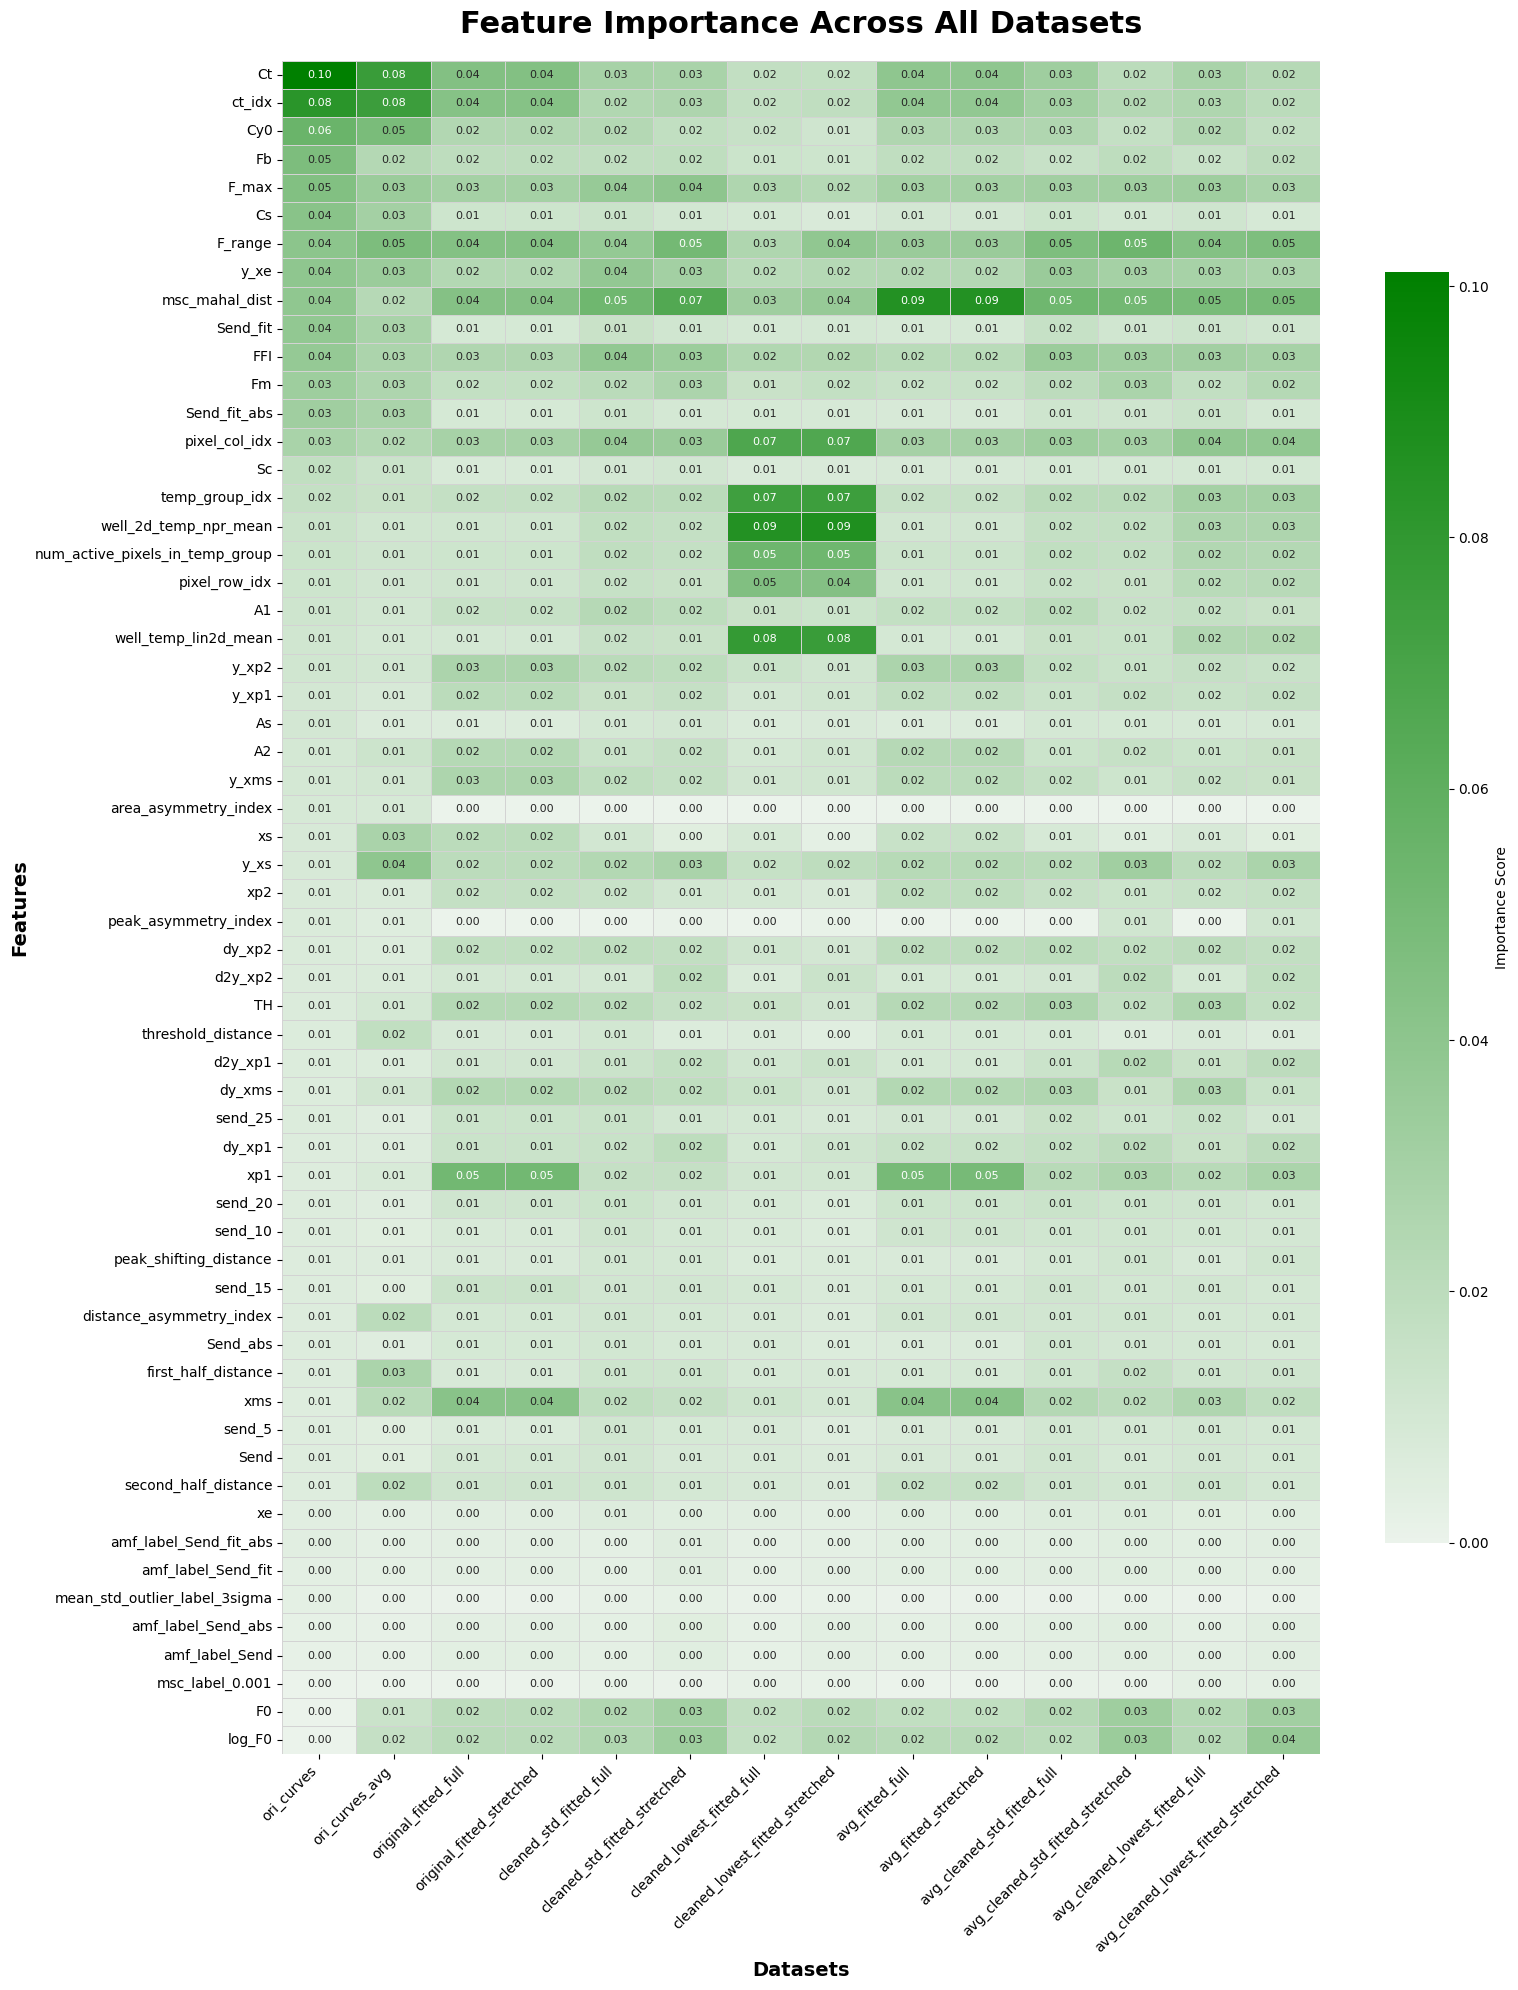

In [121]:
heatmap_data = feature_importance_df.set_index('feature')
fig, ax = plt.subplots(figsize=(16, 20))
custom_cmap = sns.light_palette("green", as_cmap=True)
sns.heatmap(
    heatmap_data, 
    cmap=custom_cmap, 
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5, 
    linecolor='lightgrey',
    cbar_kws={"shrink": .75, "label": "Importance Score"},
    ax=ax
)

ax.set_title("Feature Importance Across All Datasets", fontsize=22, fontweight='bold', pad=20)
ax.set_ylabel("Features", fontsize=14, fontweight='bold')
ax.set_xlabel("Datasets", fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()